In [1]:
import pandas as pd

df = pd.read_csv("Resume.csv")

print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  

Columns:
['ID', 'Resume_str', 'Resume_html', 'Category']

Shape:
(2484, 4)


In [2]:
!pip install nltk scikit-learn

In [3]:
import pandas as pd
import numpy as np
import nltk
import string
import re

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
df = pd.read_csv("Resume.csv")

print(df.head())

print(df.shape)

         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  
(2484, 4)


In [5]:
df = df[['Resume_str','Category']]

df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [6]:
stop_words = set(stopwords.words('english'))

def clean_resume(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', ' ', text)

    text = re.sub(r'www\S+', ' ', text)

    text = re.sub(r'@\S+', ' ', text)

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Clean_Resume"] = df["Resume_str"].apply(clean_resume)

df.head()

,Resume_str,Category,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,HR,hr director summary years experience recruitin...
3,HR SPECIALIST Summary Dedica...,HR,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,HR,hr manager skill highlights hr skills hr depar...


In [7]:
job_description = """
Data Scientist

Required Skills:

Python
Machine Learning
Deep Learning
SQL
Pandas
NumPy
Scikit-learn
Statistics
Data Analysis
Git
"""

In [8]:
job_description = clean_resume(job_description)

In [9]:
tfidf = TfidfVectorizer(max_features=5000)

resume_vectors = tfidf.fit_transform(
    df["Clean_Resume"].tolist() + [job_description]
)

In [10]:
similarity_scores = cosine_similarity(
    resume_vectors[-1],
    resume_vectors[:-1]
)

df["Match Score"] = similarity_scores.flatten() * 100

df.head()

,Resume_str,Category,Clean_Resume,Match Score
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administrator marketing associate hr admini...,6.411369
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist us hr operations summary versati...,0.083006
2,HR DIRECTOR Summary Over 2...,HR,hr director summary years experience recruitin...,0.135228
3,HR SPECIALIST Summary Dedica...,HR,hr specialist summary dedicated driven dynamic...,0.405077
4,HR MANAGER Skill Highlights ...,HR,hr manager skill highlights hr skills hr depar...,0.854999


In [11]:
ranking = df.sort_values(
    by="Match Score",
    ascending=False
)

ranking.head(10)

,Resume_str,Category,Clean_Resume,Match Score
1762,ENGINEERING AND QUALITY TECHNICIAN ...,ENGINEERING,engineering quality technician career overview...,29.417637
1218,Pavithra Shetty Summary ...,CONSULTANT,pavithra shetty summary customer oriented prin...,25.843046
2153,"CORPORATE BANKING ASSISTANT, INTERN ...",BANKING,corporate banking assistant intern objective d...,23.292508
1339,DATA ANALYST Professional Summa...,AUTOMOBILE,data analyst professional summary industrial s...,21.460452
1142,CONSULTANT Summary College g...,CONSULTANT,consultant summary college graduate interest i...,21.081873
929,"VP, PRINCIPAL Summary I am ...",AGRICULTURE,vp principal summary highly skilled growth min...,20.765988
2291,ONLINE LEARNING COORDINATOR - PROGRAM...,ARTS,online learning coordinator program training s...,20.503151
194,PROGRAM MANAGER & DESIGNER ...,DESIGNER,program manager designer professional summary ...,18.966422
1348,Highlights Prog. Languages: ...,AUTOMOBILE,highlights prog languages c yrs python yrs jav...,18.856732
331,MASTER DATA MANAGER Experie...,INFORMATION-TECHNOLOGY,master data manager experience master data man...,17.848567


In [12]:
skills = [
    "python","java","sql","machine learning","deep learning",
    "pandas","numpy","scikit-learn","tensorflow","keras",
    "excel","power bi","tableau","aws","azure","git",
    "statistics","data analysis","nlp","c++","html","css",
    "javascript","react","node","docker","kubernetes"
]

def extract_skills(text):
    found = []
    text = text.lower()

    for skill in skills:
        if skill in text:
            found.append(skill)

    return found

ranking["Skills Found"] = ranking["Clean_Resume"].apply(extract_skills)

ranking.head()

,Resume_str,Category,Clean_Resume,Match Score,Skills Found
1762,ENGINEERING AND QUALITY TECHNICIAN ...,ENGINEERING,engineering quality technician career overview...,29.417637,"[python, sql, machine learning, pandas, excel,..."
1218,Pavithra Shetty Summary ...,CONSULTANT,pavithra shetty summary customer oriented prin...,25.843046,"[python, java, sql, machine learning, azure, d..."
2153,"CORPORATE BANKING ASSISTANT, INTERN ...",BANKING,corporate banking assistant intern objective d...,23.292508,"[python, sql, machine learning]"
1339,DATA ANALYST Professional Summa...,AUTOMOBILE,data analyst professional summary industrial s...,21.460452,"[python, sql, pandas, numpy, excel, tableau, s..."
1142,CONSULTANT Summary College g...,CONSULTANT,consultant summary college graduate interest i...,21.081873,"[java, sql, excel, tableau, html, javascript]"


In [13]:
required_skills = [
    "python",
    "machine learning",
    "sql",
    "pandas",
    "numpy",
    "scikit-learn",
    "statistics",
    "git"
]

def missing_skills(skill_list):
    return list(set(required_skills) - set(skill_list))

ranking["Missing Skills"] = ranking["Skills Found"].apply(missing_skills)

ranking.head()

,Resume_str,Category,Clean_Resume,Match Score,Skills Found,Missing Skills
1762,ENGINEERING AND QUALITY TECHNICIAN ...,ENGINEERING,engineering quality technician career overview...,29.417637,"[python, sql, machine learning, pandas, excel,...","[numpy, scikit-learn, git]"
1218,Pavithra Shetty Summary ...,CONSULTANT,pavithra shetty summary customer oriented prin...,25.843046,"[python, java, sql, machine learning, azure, d...","[statistics, numpy, pandas, git, scikit-learn]"
2153,"CORPORATE BANKING ASSISTANT, INTERN ...",BANKING,corporate banking assistant intern objective d...,23.292508,"[python, sql, machine learning]","[statistics, numpy, pandas, git, scikit-learn]"
1339,DATA ANALYST Professional Summa...,AUTOMOBILE,data analyst professional summary industrial s...,21.460452,"[python, sql, pandas, numpy, excel, tableau, s...","[scikit-learn, machine learning, git]"
1142,CONSULTANT Summary College g...,CONSULTANT,consultant summary college graduate interest i...,21.081873,"[java, sql, excel, tableau, html, javascript]","[statistics, machine learning, numpy, python, ..."


In [14]:
top10 = ranking[
    ["Category",
     "Match Score",
     "Skills Found",
     "Missing Skills"]
].head(10)

top10

,Category,Match Score,Skills Found,Missing Skills
1762,ENGINEERING,29.417637,"[python, sql, machine learning, pandas, excel,...","[numpy, scikit-learn, git]"
1218,CONSULTANT,25.843046,"[python, java, sql, machine learning, azure, d...","[statistics, numpy, pandas, git, scikit-learn]"
2153,BANKING,23.292508,"[python, sql, machine learning]","[statistics, numpy, pandas, git, scikit-learn]"
1339,AUTOMOBILE,21.460452,"[python, sql, pandas, numpy, excel, tableau, s...","[scikit-learn, machine learning, git]"
1142,CONSULTANT,21.081873,"[java, sql, excel, tableau, html, javascript]","[statistics, machine learning, numpy, python, ..."
929,AGRICULTURE,20.765988,"[python, java, sql, pandas, aws]","[statistics, machine learning, numpy, git, sci..."
2291,ARTS,20.503151,[],"[statistics, machine learning, numpy, python, ..."
194,DESIGNER,18.966422,[],"[statistics, machine learning, numpy, python, ..."
1348,AUTOMOBILE,18.856732,"[python, java, sql, machine learning, excel, s...","[numpy, scikit-learn, pandas, git]"
331,INFORMATION-TECHNOLOGY,17.848567,"[python, sql, excel, tableau, aws, azure, data...","[statistics, machine learning, numpy, pandas, ..."


In [15]:
ranking.to_csv("ranking_results.csv", index=False)

print("ranking_results.csv saved successfully!")

ranking_results.csv saved successfully!


In [16]:
skill_gap = ranking[
    ["Category",
     "Match Score",
     "Missing Skills"]
]

skill_gap.to_csv("skill_gap_report.csv", index=False)

print("skill_gap_report.csv saved successfully!")

skill_gap_report.csv saved successfully!


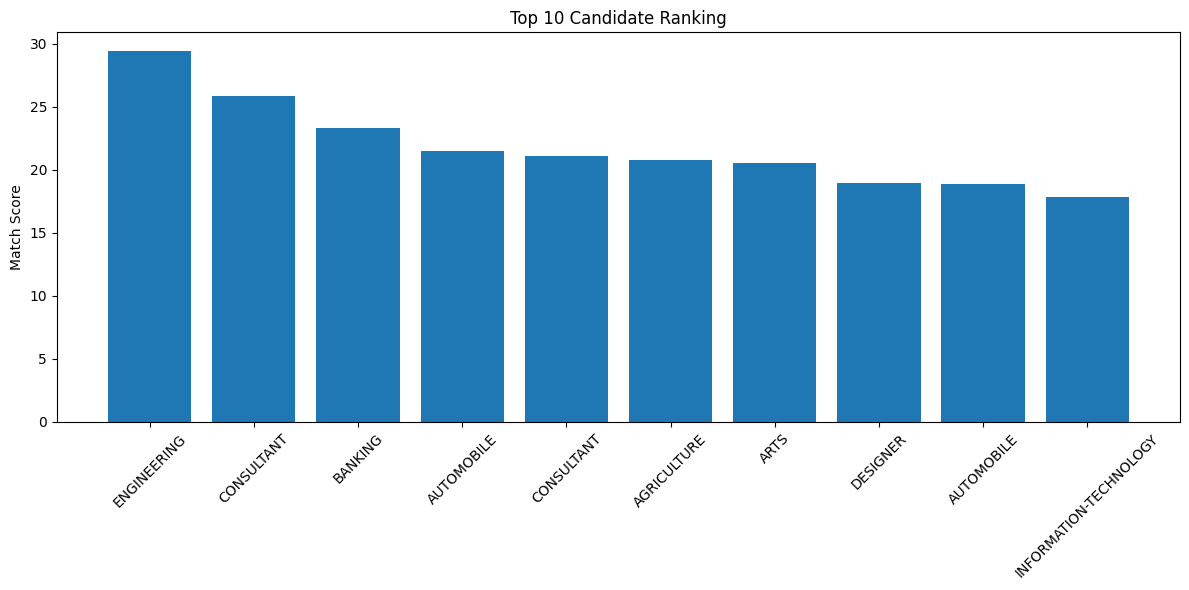

In [17]:
import matplotlib.pyplot as plt

top10_plot = ranking.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    range(len(top10_plot)),
    top10_plot["Match Score"]
)

plt.xticks(
    range(len(top10_plot)),
    top10_plot["Category"],
    rotation=45
)

plt.ylabel("Match Score")
plt.title("Top 10 Candidate Ranking")

plt.tight_layout()

plt.savefig("candidate_ranking.png", dpi=300)

plt.show()

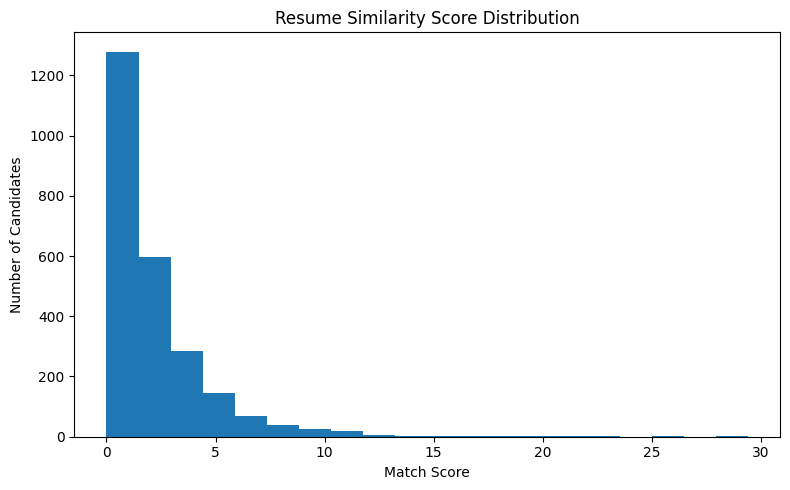

In [18]:
plt.figure(figsize=(8,5))

plt.hist(ranking["Match Score"], bins=20)

plt.xlabel("Match Score")
plt.ylabel("Number of Candidates")
plt.title("Resume Similarity Score Distribution")

plt.tight_layout()

plt.savefig("similarity_scores.png", dpi=300)

plt.show()

In [19]:
best = ranking.iloc[0]

print("========== BEST CANDIDATE ==========\n")

print("Category:")
print(best["Category"])

print("\nMatch Score:")
print(round(best["Match Score"],2))

print("\nSkills Found:")
print(best["Skills Found"])

print("\nMissing Skills:")
print(best["Missing Skills"])

========== BEST CANDIDATE ==========

Category:
ENGINEERING

Match Score:
29.42

Skills Found:
['python', 'sql', 'machine learning', 'pandas', 'excel', 'tableau', 'statistics', 'data analysis', 'html']

Missing Skills:
['numpy', 'scikit-learn', 'git']


In [20]:
new_job = input("Enter Job Description:\n")

new_job = clean_resume(new_job)

new_vector = tfidf.transform([new_job])

resume_vectors_only = tfidf.transform(df["Clean_Resume"])

scores = cosine_similarity(new_vector, resume_vectors_only)

df["Score"] = scores.flatten() * 100

best = df.sort_values("Score", ascending=False)

print(best[["Category","Score"]].head(10))

Enter Job Description:
We are looking for a Data Scientist with experience in Python, Machine Learning, Deep Learning, SQL, Pandas, NumPy, Scikit-learn, Statistics, Data Analysis, Git, and data visualization.
                    Category      Score
1218              CONSULTANT  38.580521
1762             ENGINEERING  34.758721
1339              AUTOMOBILE  27.329603
926              AGRICULTURE  24.215525
929              AGRICULTURE  21.793853
2153                 BANKING  20.652899
1303           DIGITAL-MEDIA  20.421942
331   INFORMATION-TECHNOLOGY  19.999995
1142              CONSULTANT  19.929994
1040                   SALES  19.099732
